In [1]:
!pip install pandas numpy matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = {
    "Model": [
        "BART-large-CNN",
        "T5-base",
        "Pegasus-XSum",
        "DistilBART",
        "LED-base"
    ],

    "ROUGE-1": [44.16, 42.50, 45.30, 43.20, 46.10],
    "ROUGE-2": [21.28, 20.10, 22.50, 21.00, 23.00],
    "ROUGE-L": [40.90, 38.70, 41.80, 39.90, 42.50],

    "Inference_Time_sec": [0.95, 0.80, 1.10, 0.75, 1.25],
    "Model_Size_MB": [1600, 850, 2200, 750, 1800]
}

df = pd.DataFrame(data)
df

,Model,ROUGE-1,ROUGE-2,ROUGE-L,Inference_Time_sec,Model_Size_MB
0,BART-large-CNN,44.16,21.28,40.9,0.95,1600
1,T5-base,42.50,20.10,38.7,0.80,850
2,Pegasus-XSum,45.30,22.50,41.8,1.10,2200
3,DistilBART,43.20,21.00,39.9,0.75,750
4,LED-base,46.10,23.00,42.5,1.25,1800


In [4]:
# Define criteria names
criteria = df.columns[1:]

# Convert dataframe to numpy matrix (excluding Model column)
matrix = df[criteria].values

benefit = [0, 1, 2]
cost = [3, 4]

print("Criteria:", list(criteria))
print("Benefit Criteria Index:", benefit)
print("Cost Criteria Index:", cost)

Criteria: ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'Inference_Time_sec', 'Model_Size_MB']
Benefit Criteria Index: [0, 1, 2]
Cost Criteria Index: [3, 4]


In [5]:
criteria = df.columns[1:]
matrix = df[criteria].values

norm_matrix = matrix / np.sqrt((matrix**2).sum(axis=0))
norm_df = pd.DataFrame(norm_matrix, columns=criteria)
norm_df

,ROUGE-1,ROUGE-2,ROUGE-L,Inference_Time_sec,Model_Size_MB
0,0.446086,0.440560,0.448504,0.430155,0.463330
1,0.429317,0.416130,0.424379,0.362236,0.246144
2,0.457602,0.465818,0.458373,0.498074,0.637079
3,0.436388,0.434763,0.437538,0.339596,0.217186
4,0.465683,0.476169,0.466049,0.565993,0.521247


In [6]:
weights = np.array([0.25, 0.20, 0.25, 0.15, 0.15])
weighted_matrix = norm_matrix * weights
weighted_df = pd.DataFrame(weighted_matrix, columns=criteria)
weighted_df

,ROUGE-1,ROUGE-2,ROUGE-L,Inference_Time_sec,Model_Size_MB
0,0.111521,0.088112,0.112126,0.064523,0.069500
1,0.107329,0.083226,0.106095,0.054335,0.036922
2,0.114400,0.093164,0.114593,0.074711,0.095562
3,0.109097,0.086953,0.109384,0.050939,0.032578
4,0.116421,0.095234,0.116512,0.084899,0.078187


In [7]:
benefit = [0,1,2]
cost = [3,4]

ideal_best = []
ideal_worst = []

for i in range(len(criteria)):
    if i in benefit:
        ideal_best.append(weighted_matrix[:,i].max())
        ideal_worst.append(weighted_matrix[:,i].min())
    else:
        ideal_best.append(weighted_matrix[:,i].min())
        ideal_worst.append(weighted_matrix[:,i].max())

ideal_best = np.array(ideal_best)
ideal_worst = np.array(ideal_worst)

ideal_best, ideal_worst

(array([0.1164207 , 0.09523384, 0.11651228, 0.05093941, 0.03257792]),
 array([0.10732928, 0.0832261 , 0.10609471, 0.08489901, 0.09556189]))

In [8]:
distance_best = np.sqrt(((weighted_matrix - ideal_best)**2).sum(axis=1))
distance_worst = np.sqrt(((weighted_matrix - ideal_worst)**2).sum(axis=1))

distance_best, distance_worst

(array([0.04051779, 0.01912501, 0.06741014, 0.0131537 , 0.05686338]),
 array([0.03423798, 0.06612727, 0.01802142, 0.07175006, 0.02524386]))

In [9]:
closeness = distance_worst / (distance_best + distance_worst)

df["TOPSIS_Score"] = closeness
df = df.sort_values(by="TOPSIS_Score", ascending=False)
df

,Model,ROUGE-1,ROUGE-2,ROUGE-L,Inference_Time_sec,Model_Size_MB,TOPSIS_Score
3,DistilBART,43.20,21.00,39.9,0.75,750,0.845075
1,T5-base,42.50,20.10,38.7,0.80,850,0.775666
0,BART-large-CNN,44.16,21.28,40.9,0.95,1600,0.457998
4,LED-base,46.10,23.00,42.5,1.25,1800,0.307450
2,Pegasus-XSum,45.30,22.50,41.8,1.10,2200,0.210946


In [10]:
df["Rank"] = range(1, len(df)+1)
df

,Model,ROUGE-1,ROUGE-2,ROUGE-L,Inference_Time_sec,Model_Size_MB,TOPSIS_Score,Rank
3,DistilBART,43.20,21.00,39.9,0.75,750,0.845075,1
1,T5-base,42.50,20.10,38.7,0.80,850,0.775666,2
0,BART-large-CNN,44.16,21.28,40.9,0.95,1600,0.457998,3
4,LED-base,46.10,23.00,42.5,1.25,1800,0.307450,4
2,Pegasus-XSum,45.30,22.50,41.8,1.10,2200,0.210946,5


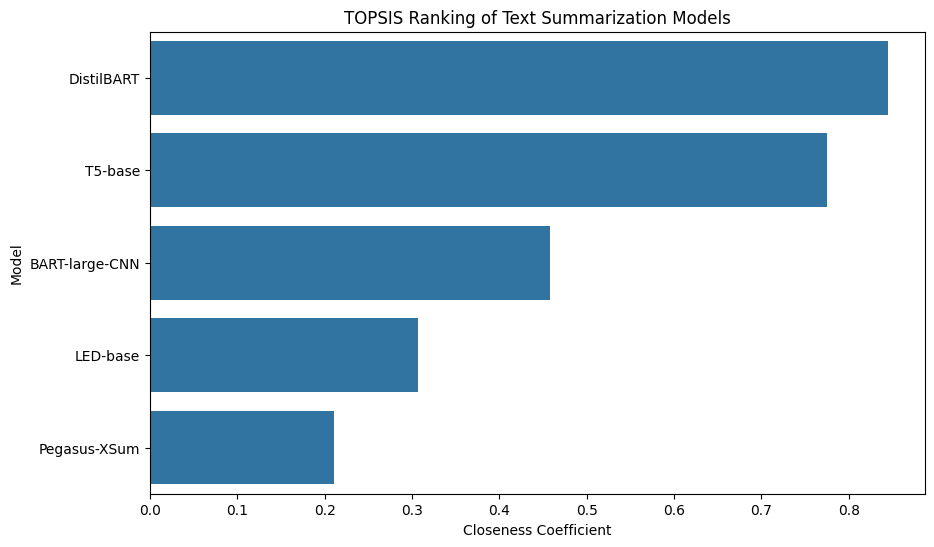

In [11]:
plt.figure(figsize=(10,6))
sns.barplot(x="TOPSIS_Score", y="Model", data=df)
plt.title("TOPSIS Ranking of Text Summarization Models")
plt.xlabel("Closeness Coefficient")
plt.ylabel("Model")
plt.show()